In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [2]:
import os
os.chdir('..')
os.getcwd()

'C:\\Users\\MaxQwerty\\Documents\\GitHub\\steam-map-project'

In [3]:
DATA_FILE = 'games_with_coords.parquet'

In [4]:
%%time

def load_data():
    """
    Загружает все данные по играм из локального файла.
    Кэширование не будет перезагружать данные при каждом действии пользователя.
    """
    try:
        df = pd.read_parquet(DATA_FILE)
        # Убираем игры, для которых не удалось рассчитать координаты
        df.dropna(subset=['x', 'y'], inplace=True)
        return df
    except FileNotFoundError:
        st.error(f"Файл с данными '{DATA_FILE}' не найден.")
        return pd.DataFrame()

games_df = load_data()

CPU times: total: 219 ms
Wall time: 165 ms


# НОВЫЙ ФИЛЬТР - разведка данных

In [5]:
import matplotlib.pyplot as plt

In [6]:
games_df.nlargest(10, 'all_reviews_count')[['all_reviews_count', 'title']]

,all_reviews_count,title
366,9310578.0,Counter-Strike 2
369,2661418.0,PUBG: BATTLEGROUNDS
371,2652657.0,Dota 2
374,2037580.0,Grand Theft Auto V Legacy
398,1472316.0,Tom Clancy's Rainbow Six® Siege X
29,1471071.0,Terraria
392,1315404.0,Rust
453,1211474.0,Team Fortress 2
320,1209271.0,Garry's Mod
378,1188983.0,Black Myth: Wukong


In [22]:
games_df.nlargest(50, 'original_price')[['all_reviews_count', 'title', 'original_price']]

,all_reviews_count,title,original_price
94001,0.0,MolCollabo v2,1900.00
52454,1.0,The Leverage Game Business Edition,999.98
52458,2.0,The Leverage Game,999.98
52935,7.0,Ascent Free-Roaming VR Experience,999.00
141807,4.0,Zekertune,615.38
52502,5.0,True Love,500.00
83750,0.0,Beach Volleyball Competition,290.00
2723,263.0,Houdini Indie,269.99
1188,62.0,VEGAS Edit 20 Steam Edition,249.00
8724,73.0,3DF Zephyr Lite Steam Edition,249.00


(array([1.61849e+05, 1.20000e+01, 3.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([      0. ,  931057.8, 1862115.6, 2793173.4, 3724231.2, 4655289. ,
        5586346.8, 6517404.6, 7448462.4, 8379520.2, 9310578. ]),
 <BarContainer object of 10 artists>)

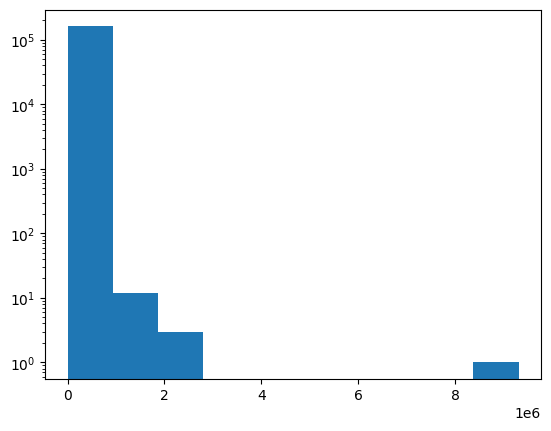

In [7]:
plt.hist(games_df['all_reviews_count'], log=True)

In [8]:
for i in range(0, 11):
    reviews_count = int(games_df['all_reviews_count'].quantile(i / 10))
    print(f"{i*10:.1f} % ->", reviews_count, "отзывов,", games_df.query("all_reviews_count >= @reviews_count").shape[0], "игр")

0.0 % -> 0 отзывов, 161865 игр
10.0 % -> 0 отзывов, 161865 игр
20.0 % -> 0 отзывов, 161865 игр
30.0 % -> 0 отзывов, 161865 игр
40.0 % -> 3 отзывов, 100989 игр
50.0 % -> 8 отзывов, 83016 игр
60.0 % -> 17 отзывов, 65176 игр
70.0 % -> 34 отзывов, 48568 игр
80.0 % -> 84 отзывов, 32450 игр
90.0 % -> 346 отзывов, 16189 игр
100.0 % -> 9310578 отзывов, 1 игр


# --- Подготовка данных ---

In [11]:
%%time

games_df['display_tags'] = games_df['tags'].str.replace('_', ' ').str.replace(',', ', ')
games_df['log_reviews'] = np.log10(games_df['all_reviews_count'] + 1)
games_df['release_date'] = pd.to_datetime(games_df['release_date'], errors='coerce')
games_df.dropna(subset=['release_date'], inplace=True)

CPU times: total: 172 ms
Wall time: 178 ms


# --- Фильтры ---

## 1. Фильтр по названию игры (для выделения)

In [6]:
%%time

sorted_game_names = sorted(games_df['title'].unique())
# selected_game = st.sidebar.selectbox("Найти и выделить игру:", options=[""] + sorted_game_names, index=0)
selected_game = "Factorio"

CPU times: total: 31.2 ms
Wall time: 36 ms


## 2. Фильтр по тегам

In [7]:
%%time

all_tags_internal = set()
games_df['tags'].str.split(',').apply(all_tags_internal.update)
tag_display_map = {tag.replace('_', ' '): tag for tag in all_tags_internal if tag}
sorted_display_tags = sorted(tag_display_map.keys())
# selected_display_tags = st.sidebar.multiselect("Теги:", options=sorted_display_tags)
# selected_display_tags = set(['Automation','Sandbox','Crafting'])
selected_display_tags = set()

CPU times: total: 219 ms
Wall time: 221 ms


## 3. Фильтр по дате релиза

In [8]:
%%time

min_date, max_date = games_df['release_date'].min().to_pydatetime(), games_df['release_date'].max().to_pydatetime()
# col1, col2 = st.sidebar.columns(2)
# with col1:
#     start_date = st.date_input("Дата релиза от:", value=min_date, min_value=min_date, max_value=max_date)
# with col2:
#     end_date = st.date_input("Дата релиза до:", value=max_date, min_value=min_date, max_value=max_date)
start_date = min_date
end_date = max_date
start_date, end_date = pd.to_datetime(start_date), pd.to_datetime(end_date)

CPU times: total: 0 ns
Wall time: 0 ns


## 4. Фильтр по цене

In [9]:
%%time

min_price, max_price = games_df['original_price'].min(), games_df['original_price'].max()
# col1, col2 = st.sidebar.columns(2)
# with col1:
#     price_from = st.number_input("Цена от ($):", min_value=min_price, max_value=max_price, value=min_price)
# with col2:
#     price_to = st.number_input("Цена до ($):", min_value=min_price, max_value=max_price, value=max_price)
price_from = min_price
price_to = max_price

CPU times: total: 0 ns
Wall time: 1e+03 μs


## 5. Фильтр по количеству отзывов

In [10]:
%%time

min_reviews, max_reviews = int(games_df['all_reviews_count'].min()), int(games_df['all_reviews_count'].max())
# col1, col2 = st.sidebar.columns(2)
# with col1:
#     reviews_from = st.number_input("Отзывов от:", min_value=min_reviews, max_value=max_reviews, value=min_reviews)
# with col2:
#     reviews_to = st.number_input("Отзывов до:", min_value=min_reviews, max_value=max_reviews, value=max_reviews)
reviews_from = min_reviews
reviews_to = max_reviews

CPU times: total: 0 ns
Wall time: 0 ns


# --- Применение фильтров ---

In [11]:
final_mask = pd.Series(True, index=games_df.index)

## Применяем фильтр по тегам

In [12]:
%%time

if selected_display_tags:
    selected_internal_tags = [tag_display_map[tag] for tag in selected_display_tags]
    tags_mask = games_df['tags'].apply(lambda ts: all(tag in ts.split(',') for tag in selected_internal_tags))
    final_mask &= tags_mask

CPU times: total: 0 ns
Wall time: 0 ns


## Применяем фильтр по дате

In [13]:
%%time

date_mask = (games_df['release_date'] >= start_date) & (games_df['release_date'] <= end_date)
final_mask &= date_mask

CPU times: total: 0 ns
Wall time: 0 ns


## Применяем фильтр по цене

In [14]:
%%time

price_mask = (games_df['original_price'] >= price_from) & (games_df['original_price'] <= price_to)
final_mask &= price_mask

CPU times: total: 0 ns
Wall time: 1e+03 μs


## Применяем фильтр по отзывам

In [15]:
%%time

reviews_mask = (games_df['all_reviews_count'] >= reviews_from) & (games_df['all_reviews_count'] <= reviews_to)
final_mask &= reviews_mask

CPU times: total: 0 ns
Wall time: 0 ns


## Определяем прозрачность на основе итоговой маски

In [16]:
%%time

games_df['opacity'] = np.where(final_mask, 1.0, 0.03)

CPU times: total: 0 ns
Wall time: 1 ms


# --- Логика выделения выбранной игры ---

In [17]:
%%time

if selected_game:
    games_df['size'] = np.where(games_df['title'] == selected_game, 12, 6)
    games_df['line_color'] = np.where(games_df['title'] == selected_game, 'red', 'rgba(0,0,0,0)')
    games_df['line_width'] = np.where(games_df['title'] == selected_game, 2, 0)
    games_df.loc[games_df['title'] == selected_game, 'opacity'] = 1.0
else:
    games_df['size'] = 6
    games_df['line_color'] = 'rgba(0,0,0,0)'
    games_df['line_width'] = 0

games_df['sort_order'] = np.where(games_df['title'] == selected_game, 2, games_df['opacity'])
games_df = games_df.sort_values(by=['sort_order', 'release_date'])

CPU times: total: 46.9 ms
Wall time: 49.5 ms


# --- Создание интерактивного графика ---

In [19]:
%%time

visible_games = games_df[games_df['opacity'] == 1.0]
background_games = games_df[games_df['opacity'] < 1.0]

CPU times: total: 0 ns
Wall time: 2 ms


## 1. Добавляем фоновые точки (без hover-информации) с WebGL

In [20]:
fig = go.Figure()

fig.add_trace(go.Scattergl(
    x=background_games['x'],
    y=background_games['y'],
    mode='markers',
    marker=dict(
        color=background_games['log_reviews'],
        colorscale=px.colors.sequential.Viridis,
        opacity=0.03,
        size=background_games['size'],
        cmin=games_df['log_reviews'].min(),
        cmax=games_df['log_reviews'].max(),
        showscale=False
    ),
    hoverinfo='none',
    showlegend=False
));

## 2. Добавляем видимые точки (с hover-информацией) с WebGL для производительности

In [21]:
%%time

fig.add_trace(go.Scattergl(
    x=visible_games['x'],
    y=visible_games['y'],
    customdata=visible_games[['display_tags', 'all_reviews_count']],
    mode='markers',
    marker=dict(
        color=visible_games['log_reviews'],
        colorscale=px.colors.sequential.Viridis,
        opacity=1.0,
        size=visible_games['size'],
        cmin=games_df['log_reviews'].min(),
        cmax=games_df['log_reviews'].max(),
        colorbar=dict(title="Отзывы (log10)"),
        line=dict(
            color=visible_games['line_color'],
            width=visible_games['line_width']
        )
    ),
    hovertemplate="<b>%{text}</b><br><br>" +
                  "Теги: %{customdata[0]}<br>" +
                  "Отзывы: %{customdata[1]}<extra></extra>",
    text=visible_games['title'],
    showlegend=False
));

CPU times: total: 203 ms
Wall time: 204 ms


## Обновляем общие настройки layout

In [22]:
%%time

fig.update_layout(
    title="2D-проекция игрового пространства Steam",
    xaxis_title=None,
    yaxis_title=None,
    xaxis=dict(showticklabels=False, showgrid=False, zeroline=False),
    yaxis=dict(
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        scaleanchor="x",
        scaleratio=1,
    ),
    dragmode='pan',
    barmode='overlay',
    showlegend=False,
    height=1200
);

CPU times: total: 0 ns
Wall time: 8 ms


## Отображение графика

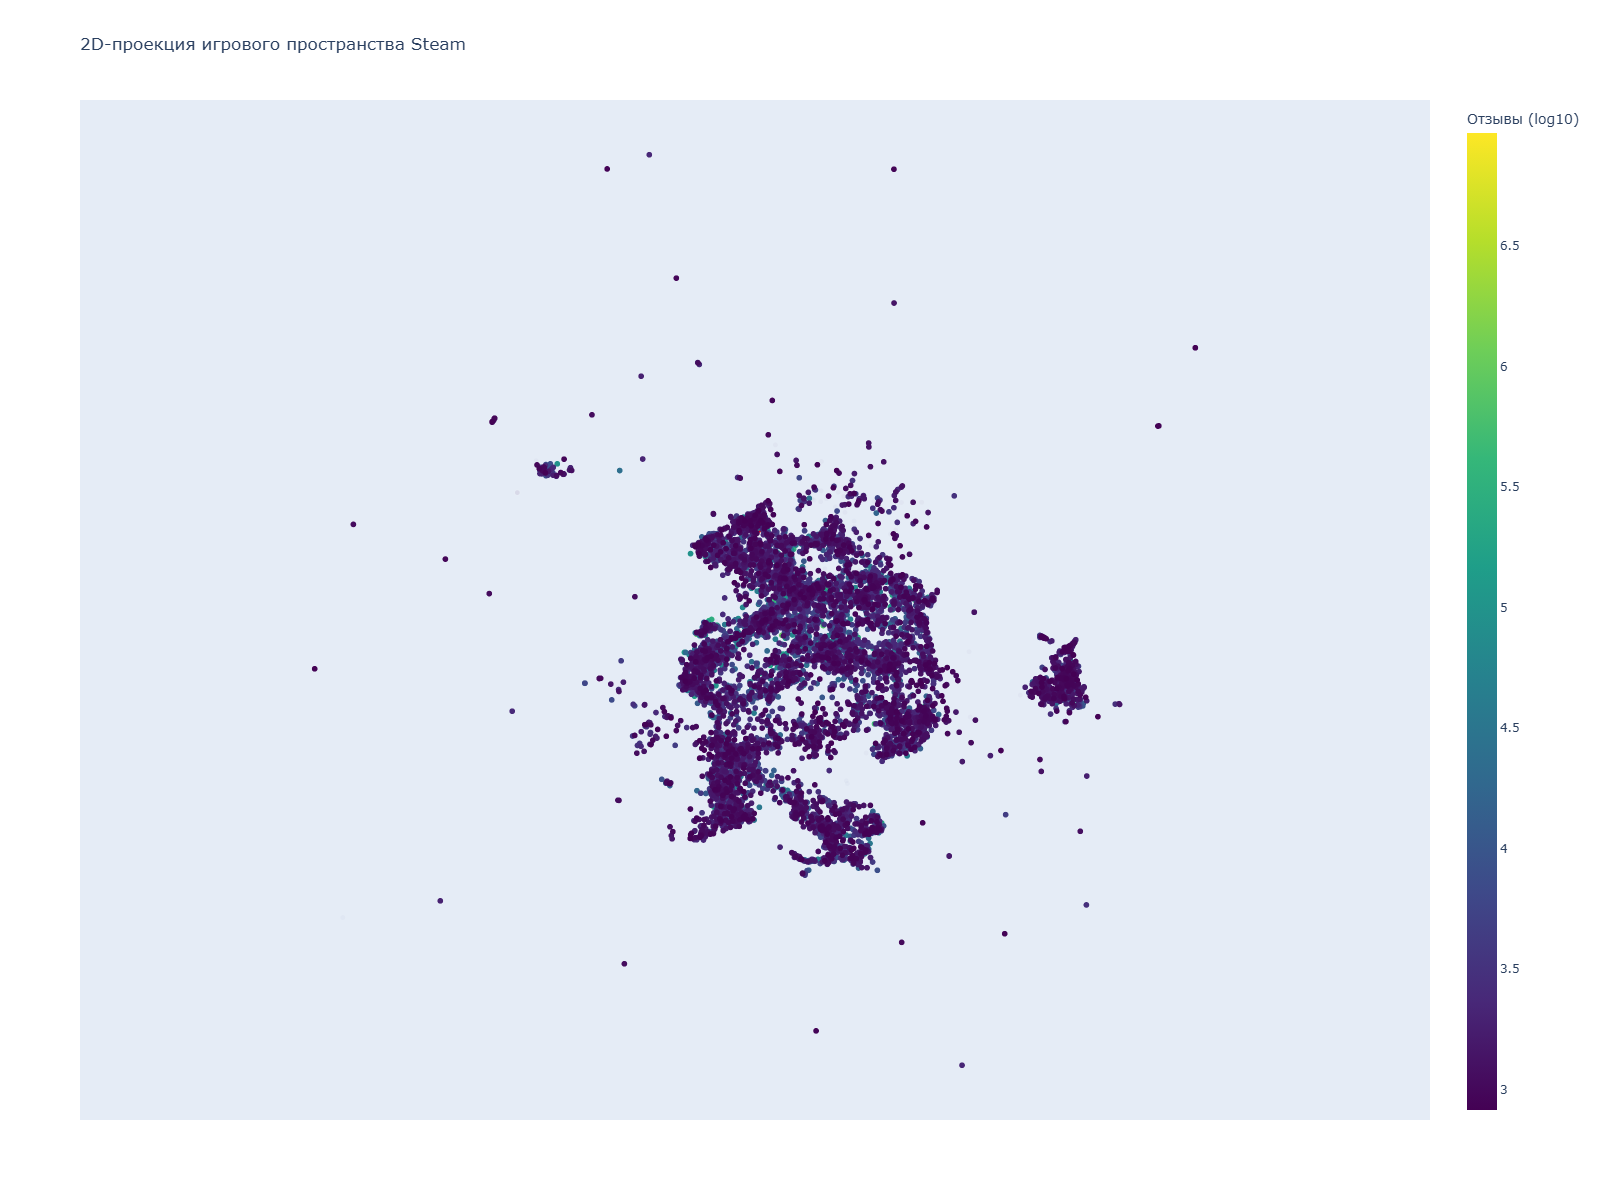

In [23]:
fig